In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [120]:
df = pd.read_csv("/Users/aysia/Downloads/country_year_modeling_dataset.csv")
df.head()
#every row is one country in one year 

,iso3c,country,year,mmr,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,disaster_exposure
0,AFE,Africa Eastern and Southern,2000,612.0,706.727261,5.657523,5.549893,40.977528,26.783513,0.0,3061.85,NaN
1,AFE,Africa Eastern and Southern,2001,586.0,625.827815,5.803267,5.501766,98.500000,26.809926,0.0,3255.66,NaN
2,AFE,Africa Eastern and Southern,2002,564.0,630.512328,5.408213,5.449696,98.900000,26.718091,0.0,3474.73,NaN
3,AFE,Africa Eastern and Southern,2003,537.0,815.432296,5.989670,5.407328,98.900000,26.580603,0.0,3506.74,NaN
4,AFE,Africa Eastern and Southern,2004,516.0,989.015464,6.069927,5.381308,98.500000,26.475208,0.0,3467.88,NaN


In [122]:
print("Shape:", df.shape)
print(df.info())
#5712 instances and 12 variables
#no missing values
#all numeric predictors
#ISO3 and country are categorical identifiers

Shape: (5712, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5712 entries, 0 to 5711
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   iso3c                5712 non-null   object 
 1   country              5712 non-null   object 
 2   year                 5712 non-null   int64  
 3   mmr                  5712 non-null   float64
 4   gdp_pc               5712 non-null   float64
 5   health_exp_gdp       5712 non-null   float64
 6   fertility            5712 non-null   float64
 7   skilled_births       5474 non-null   float64
 8   pm25                 4998 non-null   float64
 9   heat_index35_days    4998 non-null   float64
 10  cooling_degree_days  4998 non-null   float64
 11  disaster_exposure    238 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 535.6+ KB
None


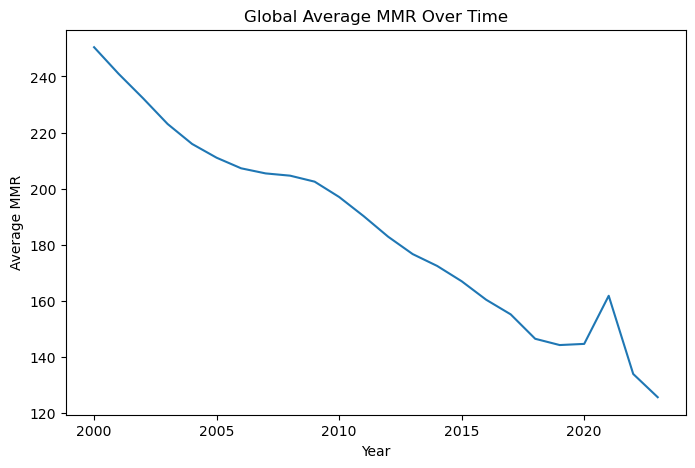

In [124]:
#global time trend of mmr
global_trend = df.groupby("year")["mmr"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(global_trend["year"], global_trend["mmr"])
plt.title("Global Average MMR Over Time")
plt.xlabel("Year")
plt.ylabel("Average MMR")
plt.show()

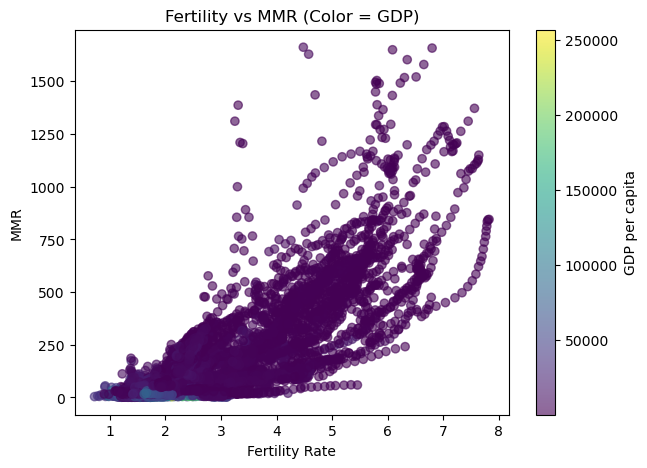

In [23]:
#fertility vs mmr scatterplot
plt.figure(figsize=(7,5))
plt.scatter(df["fertility"], df["mmr"], c=df["gdp_pc"], cmap="viridis", alpha=0.6)
plt.colorbar(label="GDP per capita")
plt.xlabel("Fertility Rate")
plt.ylabel("MMR")
plt.title("Fertility vs MMR (Color = GDP)")
plt.show()

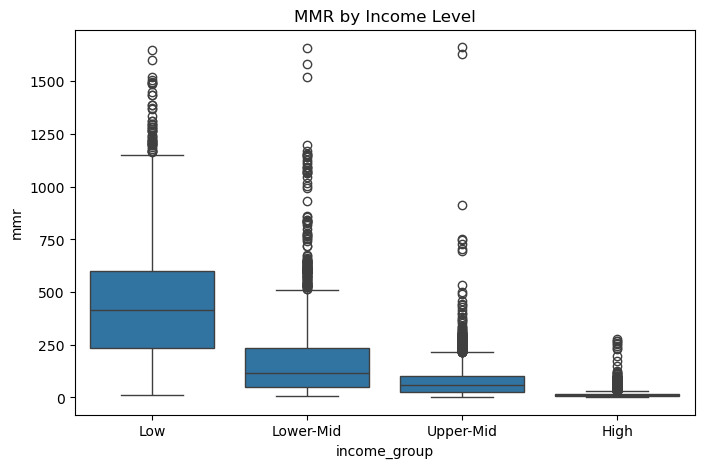

In [24]:
#boxplot for income group comparison
df["income_group"] = pd.qcut(df["gdp_pc"], 4, labels=["Low", "Lower-Mid", "Upper-Mid", "High"])

plt.figure(figsize=(8,5))
sns.boxplot(x="income_group", y="mmr", data=df)
plt.title("MMR by Income Level")
plt.show()

In [26]:
#outlier analysis
df.sort_values("mmr", ascending=False).head(10)

,iso3c,country,year,mmr,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,disaster_exposure,log_mmr,income_group
4673,SSD,South Sudan,2017,1662.0,5955.297386,22.113224,4.483,99.4,35.066004,1.15,6838.91,NaN,7.416378,Upper-Mid
4656,SSD,South Sudan,2000,1658.0,1668.567801,4.888191,6.803,90.5,38.432042,0.30,5927.26,NaN,7.413970,Lower-Mid
763,CAF,Central African Republic,2019,1650.0,449.228468,7.760815,6.090,40.3,34.914376,1.92,5389.94,NaN,7.409136,Low
4672,SSD,South Sudan,2016,1629.0,5598.486226,5.850965,4.579,99.0,35.298539,9.45,6941.86,NaN,7.396335,Upper-Mid
4512,SLE,Sierra Leone,2000,1603.0,143.743743,5.290865,6.355,37.1,41.683185,0.03,4631.46,NaN,7.380256,Low
4657,SSD,South Sudan,2001,1580.0,1762.211862,4.950750,6.654,98.5,38.280684,2.07,5882.00,NaN,7.365813,Lower-Mid
4658,SSD,South Sudan,2002,1521.0,1852.902902,5.062279,6.515,98.9,37.910291,2.78,6212.37,NaN,7.327781,Lower-Mid
4513,SLE,Sierra Leone,2001,1518.0,358.315716,5.221835,6.305,98.5,41.761882,0.00,4710.42,NaN,7.325808,Low
745,CAF,Central African Republic,2001,1504.0,237.951703,4.010440,5.807,98.5,33.930573,0.57,4625.52,NaN,7.316548,Low
746,CAF,Central African Republic,2002,1496.0,248.639291,4.236336,5.785,98.9,33.501626,0.34,4796.74,NaN,7.311218,Low


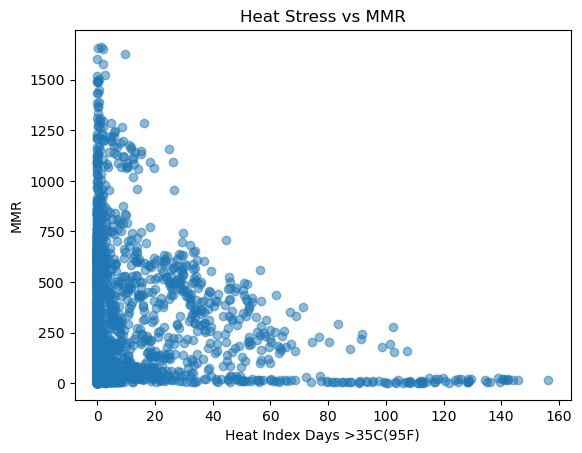

In [30]:
#heat index vs mmr
plt.scatter(df["heat_index35_days"], df["mmr"], alpha=0.5)
plt.xlabel("Heat Index Days >35C(95F)")
plt.ylabel("MMR")
plt.title("Heat Stress vs MMR")
plt.show()

In [134]:
# Ensure year is int and iso3c clean
df["year"] = df["year"].astype(int)
df["iso3c"] = df["iso3c"].astype(str).str.strip().str.upper()

#because of the skewness, applied a log transformation to stabilize variance and improve model performance
#log_mmr = log(1 + MMR)
# If log_mmr isn't in the file, create it
if "log_mmr" not in df.columns:
    df["log_mmr"] = np.log1p(df["mmr"])

target = "log_mmr"

features = [
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days",
    "cooling_degree_days",
]

# Keep only features that exist
features = [c for c in features if c in df.columns]
print("Using features:", features)

Using features: ['gdp_pc', 'health_exp_gdp', 'fertility', 'skilled_births', 'pm25', 'heat_index35_days', 'cooling_degree_days']


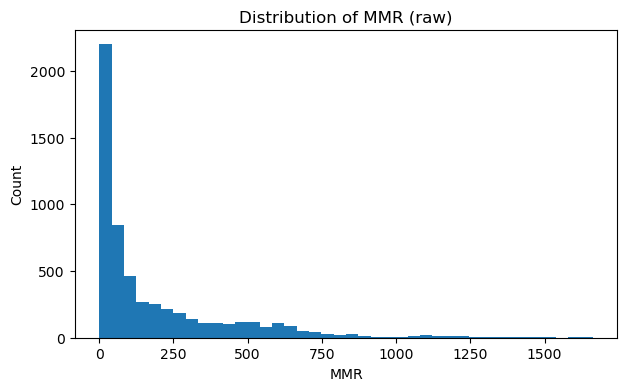

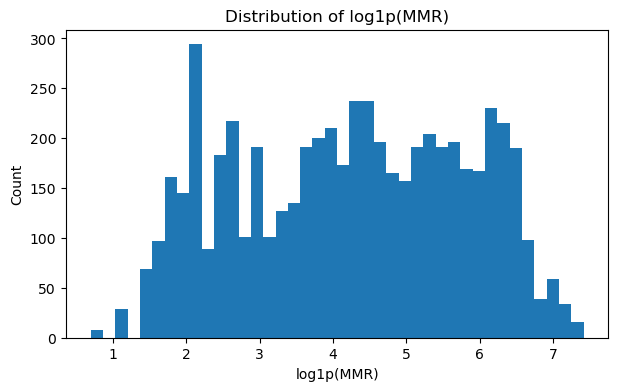

,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,mmr,log_mmr
count,5712.000000,5712.000000,5712.000000,5474.000000,4998.000000,4998.000000,4998.000000,5712.000000,5712.000000
mean,12315.948257,6.164527,2.918973,94.544927,28.290154,5.448285,3225.090508,185.514006,4.244341
std,20211.618338,2.783244,1.484681,13.586242,16.526619,17.167828,1966.696803,250.643383,1.552791
min,109.593814,1.222602,0.721000,5.600000,4.895181,0.000000,0.000000,1.000000,0.693147
25%,1451.379924,4.229262,1.730000,98.000000,16.432426,0.000000,1232.815000,17.000000,2.890372
50%,4344.474745,5.419955,2.414000,98.800000,23.448815,0.000000,3506.740000,74.000000,4.317488
75%,13028.965520,7.735592,3.913000,99.250000,38.942962,0.890000,4748.857500,258.000000,5.556828
max,256799.788613,27.089685,7.829000,100.000000,107.144665,156.290000,7541.700000,1662.000000,7.416378


In [136]:
# Distribution of MMR (raw)
plt.figure(figsize=(7,4))
plt.hist(df["mmr"].dropna(), bins=40)
plt.title("Distribution of MMR (raw)")
plt.xlabel("MMR")
plt.ylabel("Count")
plt.show()

# Distribution of log(MMR)
plt.figure(figsize=(7,4))
plt.hist(df[target].dropna(), bins=40)
plt.title("Distribution of log1p(MMR)")
plt.xlabel("log1p(MMR)")
plt.ylabel("Count")
plt.show()

# Basic summary stats
display(df[features + ["mmr", target]].describe())

In [138]:
#included in model: gdp per capita, health expenditure, fertility rate, skilled birth attendance, pm2.5 exposure(pollution), extreme heat dates, and cooling degree days
#variables represent economic, health systems, demographic, and climate drivers on MM
features = [
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days",
    "cooling_degree_days"
]

features = [f for f in features if f in df.columns]

In [132]:
missing_counts = df[features].isna().sum().sort_values(ascending=False)
print("Missing counts:\n", missing_counts)

print("\nRows with any missing feature:", df[features].isna().any(axis=1).sum())

Missing counts:
 pm25                   714
heat_index35_days      714
cooling_degree_days    714
skilled_births         238
gdp_pc                   0
health_exp_gdp           0
fertility                0
dtype: int64

Rows with any missing feature: 714


In [34]:
#pandas
corr_matrix = df[features + ["mmr"]].corr(method="pearson")
corr_matrix

,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,mmr
gdp_pc,1.000000,0.295720,-0.415428,0.170145,-0.321924,0.067129,-0.330502,-0.357889
health_exp_gdp,0.295720,1.000000,-0.298516,0.158257,-0.451062,-0.260509,-0.310855,-0.228044
fertility,-0.415428,-0.298516,1.000000,-0.325972,0.460220,0.056123,0.441608,0.817453
skilled_births,0.170145,0.158257,-0.325972,1.000000,-0.228916,-0.089311,-0.126834,-0.330501
pm25,-0.321924,-0.451062,0.460220,-0.228916,1.000000,0.485131,0.388320,0.437541
heat_index35_days,0.067129,-0.260509,0.056123,-0.089311,0.485131,1.000000,0.390430,0.005285
cooling_degree_days,-0.330502,-0.310855,0.441608,-0.126834,0.388320,0.390430,1.000000,0.347405
mmr,-0.357889,-0.228044,0.817453,-0.330501,0.437541,0.005285,0.347405,1.000000


,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,mmr
gdp_pc,1.000000,0.295720,-0.415428,0.166429,-0.292763,0.050777,-0.289742,-0.357889
health_exp_gdp,0.295720,1.000000,-0.298516,0.156052,-0.417527,-0.245674,-0.277784,-0.228044
fertility,-0.415428,-0.298516,1.000000,-0.324054,0.445799,0.064239,0.414480,0.817453
skilled_births,0.166429,0.156052,-0.324054,1.000000,-0.236544,-0.100062,-0.119708,-0.329595
pm25,-0.292763,-0.417527,0.445799,-0.236544,1.000000,0.491029,0.380548,0.427479
heat_index35_days,0.050777,-0.245674,0.064239,-0.100062,0.491029,1.000000,0.381859,0.012647
cooling_degree_days,-0.289742,-0.277784,0.414480,-0.119708,0.380548,0.381859,1.000000,0.331782
mmr,-0.357889,-0.228044,0.817453,-0.329595,0.427479,0.012647,0.331782,1.000000


,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,mmr
gdp_pc,1.000000,0.295720,-0.415428,0.166429,-0.292763,0.050777,-0.289742,-0.357889
health_exp_gdp,0.295720,1.000000,-0.298516,0.156052,-0.417527,-0.245674,-0.277784,-0.228044
fertility,-0.415428,-0.298516,1.000000,-0.324054,0.445799,0.064239,0.414480,0.817453
skilled_births,0.166429,0.156052,-0.324054,1.000000,-0.236544,-0.100062,-0.119708,-0.329595
pm25,-0.292763,-0.417527,0.445799,-0.236544,1.000000,0.491029,0.380548,0.427479
heat_index35_days,0.050777,-0.245674,0.064239,-0.100062,0.491029,1.000000,0.381859,0.012647
cooling_degree_days,-0.289742,-0.277784,0.414480,-0.119708,0.380548,0.381859,1.000000,0.331782
mmr,-0.357889,-0.228044,0.817453,-0.329595,0.427479,0.012647,0.331782,1.000000


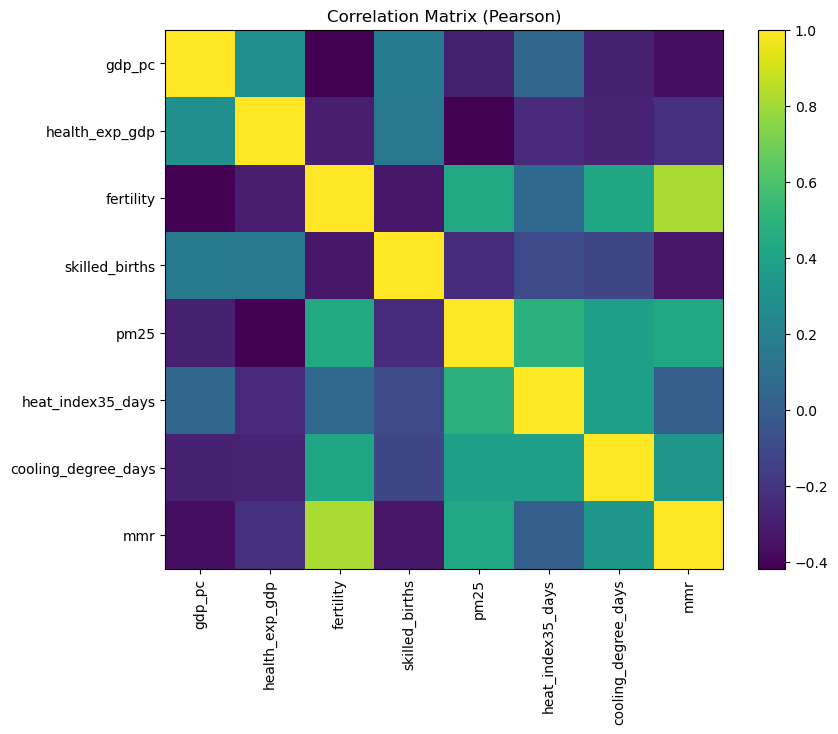

In [140]:
tmp = df[features + ["mmr"]].copy()

# quick fill for correlation only (median)
tmp = tmp.apply(lambda s: s.fillna(s.median()) if s.dtype != "object" else s)

corr_pd = tmp.corr(method="pearson")
display(corr_pd)

corr_np = np.corrcoef(tmp.values.T)
corr_np_df = pd.DataFrame(corr_np, index=tmp.columns, columns=tmp.columns)
display(corr_np_df)

# Heatmap-style plot without seaborn (since you're okay with plain matplotlib)
plt.figure(figsize=(9,7))
plt.imshow(corr_pd.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_pd.columns)), corr_pd.columns, rotation=90)
plt.yticks(range(len(corr_pd.index)), corr_pd.index)
plt.title("Correlation Matrix (Pearson)")
plt.show()

In [38]:
#Fertility has very strong positive correlation with MMR (0.82)
#GDP per capita has moderate negative correlation (-0.36)
#Skilled births negatively correlated (-0.33)
#PM2.5 moderately positively correlated (0.43)
#Climate variables show weaker correlations
#Fertility is the strongest linear predictor.

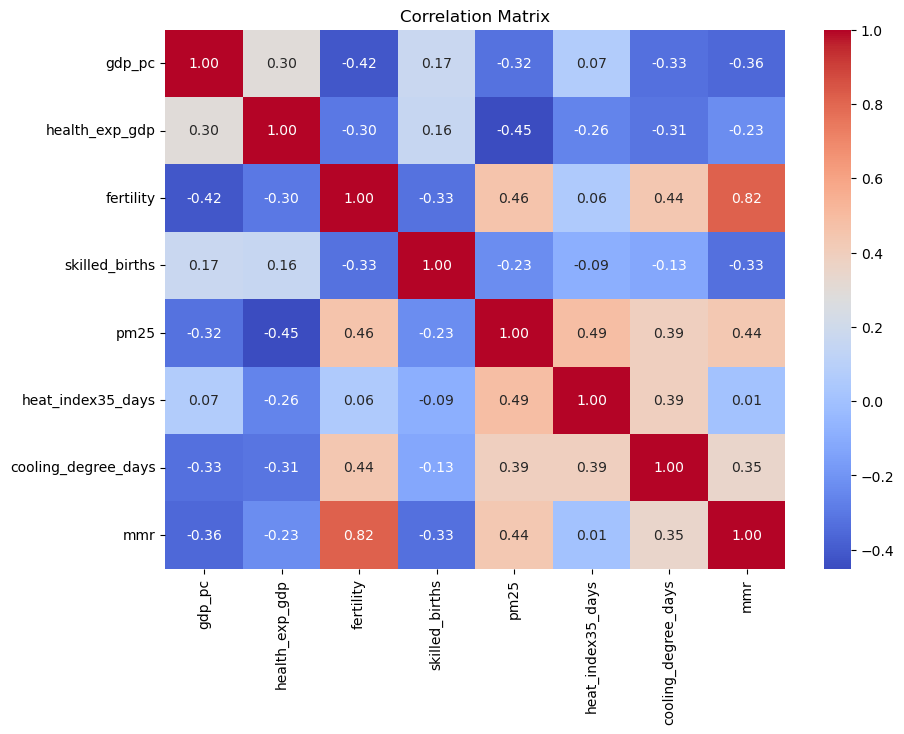

In [142]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [144]:
#to prevent future data leakage and mimic real-world forecasting
#Training data: Years ≤ 2018
#Test data: Years > 2018

split_year = 2018

train = df[df["year"] <= split_year].copy()
test  = df[df["year"] > split_year].copy()

X_train = train[features]
y_train = train[target]

X_test  = test[features]
y_test  = test[target]

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (4522, 7)  Test: (1190, 7)


In [146]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

In [152]:
models = {
    #linear:
    "Linear Regression": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", Lasso(alpha=0.01))
    ]),
    #kernel based
    "SVR (RBF)": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
    ]),
    #distance based
    "KNN": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", KNeighborsRegressor(n_neighbors=10))
    ]),
    #neural network
    "MLP Regressor": Pipeline([
        ("prep", numeric_transformer_scaled),
        ("model", MLPRegressor(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42))
    ]),
    #tree based
    "Random Forest": Pipeline([
        ("prep", numeric_transformer_unscaled), 
        ("model", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", numeric_transformer_unscaled),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
}

In [154]:
# evaluate models using MAE, RMSE, R2
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)

    preds = np.expm1(preds_log)
    true = np.expm1(y_test)

    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mean_squared_error(true, preds))
    r2 = r2_score(y_test, preds_log)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 (log-scale)": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Model,MAE,RMSE,R2 (log-scale)
3,SVR (RBF),60.938200,113.747486,0.718699
6,Random Forest,62.436804,119.158152,0.719637
7,Gradient Boosting,64.273170,120.135644,0.741286
4,KNN,65.863559,123.697691,0.701313
5,MLP Regressor,69.135747,127.977869,0.634996
2,Lasso,73.669687,133.877545,0.670970
1,Ridge,73.641333,134.690393,0.670396
0,Linear Regression,73.641253,134.693494,0.670404


In [56]:
#best model is SVR and indicates the importance of nonlinear relationships
#fertility, pollutions, and economic effects are probably non linear 

In [156]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_model.fit(X_train, y_train)

print("Best model:", best_name)

Best model: SVR (RBF)


In [60]:
#scatter plot compares predicted MMR vs actual MMR. The dashed diagonal line represents perfect predictions. Points close to the line indicate better model performance.

In [62]:
#strong clustering at low MMR means model performs well for low-risk countries
#wider spread at high MMR means model struggles with extreme values
#slight underprediction at very high MMR levels

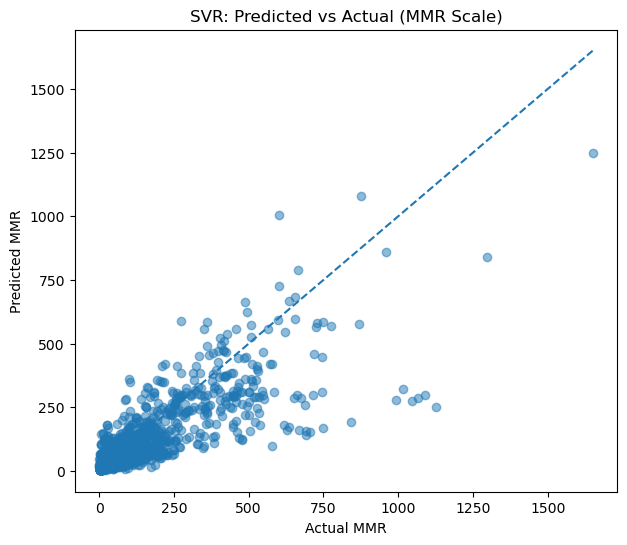

In [158]:
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

plt.figure(figsize=(7,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle="--")

plt.xlabel("Actual MMR")
plt.ylabel("Predicted MMR")
plt.title("SVR: Predicted vs Actual (MMR Scale)")
plt.show()

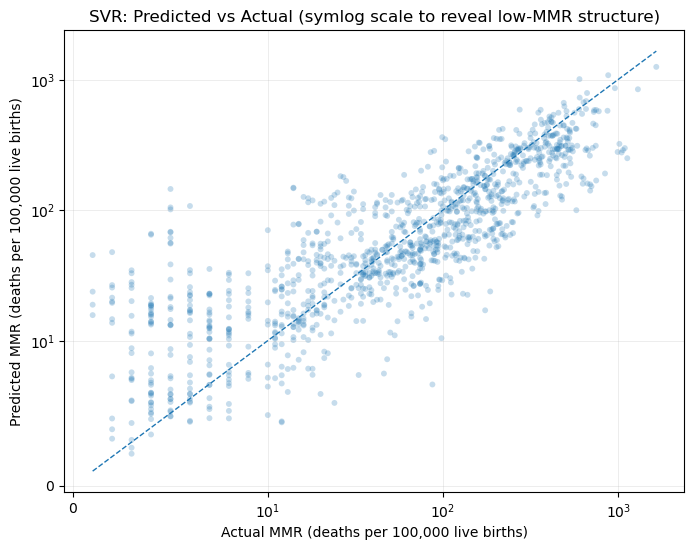

In [165]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_true, y_pred,
    s=18, alpha=0.25, edgecolors="none"
)

lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

plt.xscale("symlog", linthresh=10)   # linear-ish near 0, log after 10
plt.yscale("symlog", linthresh=10)

plt.xlabel("Actual MMR (deaths per 100,000 live births)")
plt.ylabel("Predicted MMR (deaths per 100,000 live births)")
plt.title("SVR: Predicted vs Actual (symlog scale to reveal low-MMR structure)")
plt.grid(True, which="both", linewidth=0.4, alpha=0.4)
plt.show()

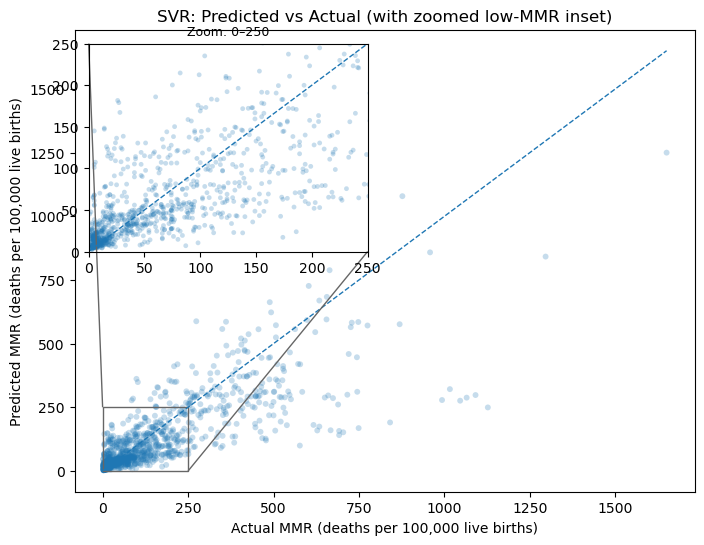

In [168]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(y_true, y_pred, s=18, alpha=0.25, edgecolors="none")

lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

ax.set_xlabel("Actual MMR (deaths per 100,000 live births)")
ax.set_ylabel("Predicted MMR (deaths per 100,000 live births)")
ax.set_title("SVR: Predicted vs Actual (with zoomed low-MMR inset)")

# Inset zoom (adjust these limits if you want)
axins = inset_axes(ax, width="45%", height="45%", loc="upper left", borderpad=1)
axins.scatter(y_true, y_pred, s=12, alpha=0.25, edgecolors="none")
axins.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

axins.set_xlim(0, 250)
axins.set_ylim(0, 250)
axins.set_title("Zoom: 0–250", fontsize=9)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")
plt.show()

In [66]:
#residual analysis
#slight funnel shape meaning heteroskedasticity
#larger variance at high predicted MMR
#model struggles more with extreme maternal mortality

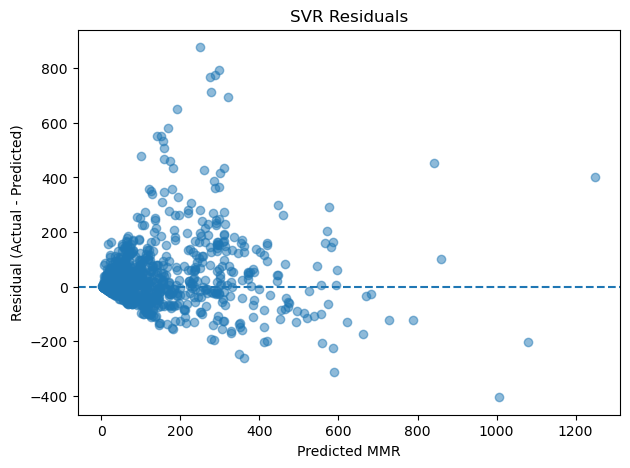

In [160]:
residuals = y_true - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted MMR")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("SVR Residuals")
plt.show()

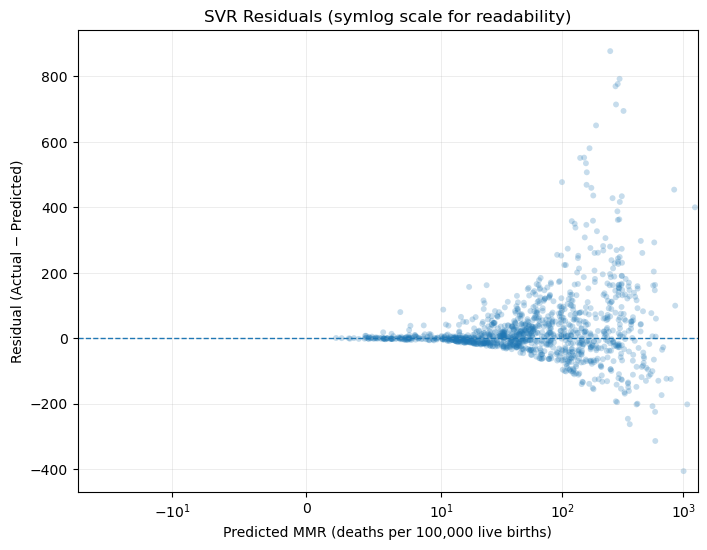

In [170]:
residuals = y_true - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    s=18,
    alpha=0.25,
    edgecolors="none"
)

plt.axhline(0, linestyle="--", linewidth=1)

# spread out dense region near zero
plt.xscale("symlog", linthresh=10)

plt.xlabel("Predicted MMR (deaths per 100,000 live births)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("SVR Residuals (symlog scale for readability)")

plt.grid(True, which="both", linewidth=0.4, alpha=0.4)

plt.show()

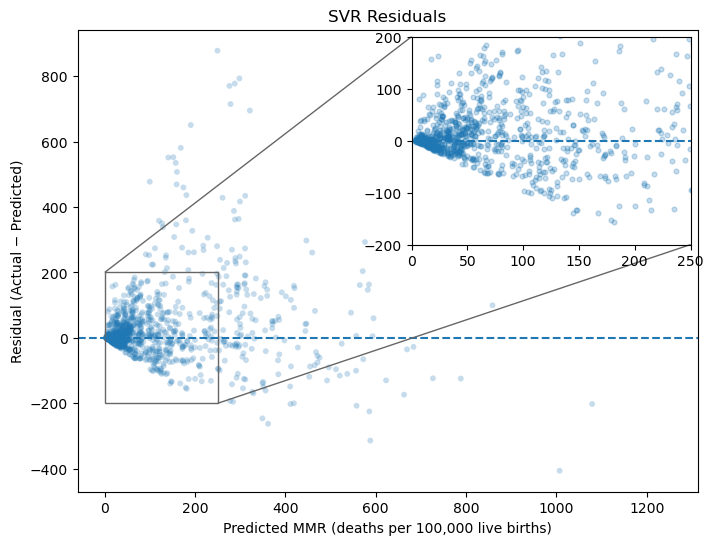

In [172]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(y_pred, residuals, s=18, alpha=0.25, edgecolors="none")
ax.axhline(0, linestyle="--")

ax.set_xlabel("Predicted MMR (deaths per 100,000 live births)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("SVR Residuals")

# inset zoom
axins = inset_axes(ax, width="45%", height="45%", loc="upper right")
axins.scatter(y_pred, residuals, s=12, alpha=0.25)
axins.axhline(0, linestyle="--")

axins.set_xlim(0,250)
axins.set_ylim(-200,200)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")

plt.show()

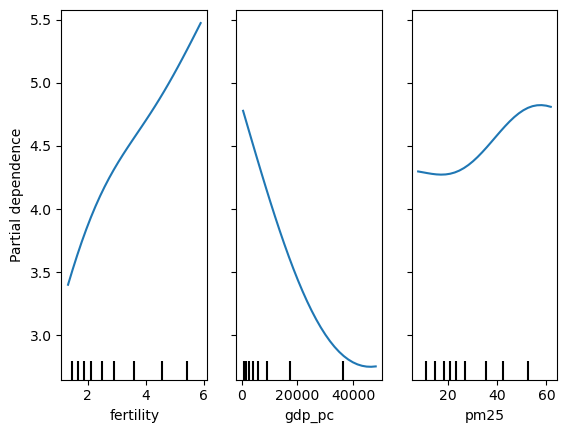

In [175]:
#partial dependence plot to show how individual features affect predicted MMR
PartialDependenceDisplay.from_estimator(
    best_model, X_train, features=["fertility", "gdp_pc", "pm25"], grid_resolution=30
)
plt.show()

In [73]:
#fertility graph- strong upward relationship, higher fertility means higher predicted MMR
#gdp graph- negative relationship, higher gdp means lower predicted mmr
#pm2.5- positive nonlinear relationship, higher air pollution means higher risk of MMR

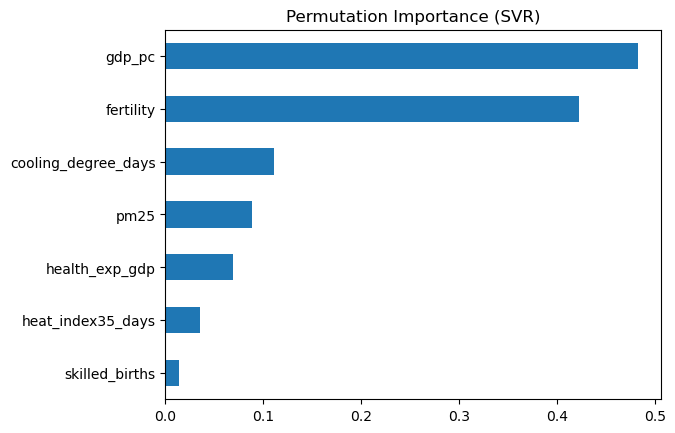

In [163]:
#permutation feature importance
#permutation importance measures how much model performance decreases when a feature is randomly shuffled

from sklearn.inspection import permutation_importance

result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)
perm_imp = pd.Series(result.importances_mean, index=features).sort_values()

perm_imp.plot(kind="barh", title="Permutation Importance (SVR)")
plt.show()

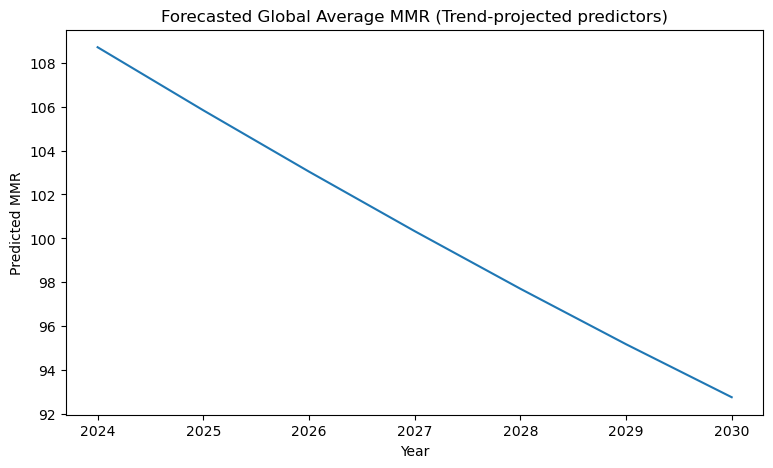

In [176]:
#forecasted global average MMR (2024–2030)
#using trend-projected predictors, so the model forecasts future global average maternal mortality rates

#train on full historical data
X_all = df[features]
y_all = df["log_mmr"]
best_model.fit(X_all, y_all)

#latest row per country
latest = df.sort_values("year").groupby("iso3c").tail(1).copy()

future_years = list(range(df["year"].max()+1, 2031))
future = pd.concat([latest.assign(year=y) for y in future_years], ignore_index=True)

#trend-project predictors per country
def project_feature(df_hist, col, horizon_years):
    df_hist = df_hist.sort_values("year")
    if df_hist[col].notna().sum() < 3:
        return np.repeat(df_hist[col].iloc[-1], len(horizon_years))

    x = df_hist["year"].values
    y = df_hist[col].values
    slope, intercept = np.polyfit(x, y, 1)
    return intercept + slope*np.array(horizon_years)

hist = df.copy()
projected = []

for iso, g in hist.groupby("iso3c"):
    yrs = future_years
    row = {"iso3c": iso}
    for col in features:
        row[col] = project_feature(g, col, yrs)
    tmp = pd.DataFrame(row)
    tmp["year"] = yrs
    projected.append(tmp)

proj_df = pd.concat(projected, ignore_index=True)

#predict
proj_df["pred_log_mmr"] = best_model.predict(proj_df[features])
proj_df["pred_mmr"] = np.expm1(proj_df["pred_log_mmr"])

global_forecast = proj_df.groupby("year")["pred_mmr"].mean().reset_index()

plt.figure(figsize=(9,5))
plt.plot(global_forecast["year"], global_forecast["pred_mmr"])
plt.title("Forecasted Global Average MMR (Trend-projected predictors)")
plt.xlabel("Year")
plt.ylabel("Predicted MMR")
plt.show()

In [201]:
future_years = list(range(2024, 2031))

future = []

for year in future_years:

    temp = latest.copy()

    years_ahead = year - 2023

    # apply gradual trends
    temp["year"] = year
    temp["gdp_pc"] = temp["gdp_pc"] * (1.03 ** years_ahead)
    temp["health_exp_gdp"] = temp["health_exp_gdp"] * (1.02 ** years_ahead)
    temp["fertility"] = temp["fertility"] * (0.985 ** years_ahead)

    future.append(temp)

future = pd.concat(future, ignore_index=True)

In [203]:
future_baseline = future.copy()

In [205]:
#Scenario 1: health investment
#assume +20% health spending and +10% skilled birth attendance

future_health = future.copy()

future_health["health_exp_gdp"] *= 1.25
future_health["skilled_births"] *= 1.10

In [207]:
#scenario 2: climate stress
#assume PM2.5 increases 15% and heat index days increase 20%
future_climate = future.copy()

future_climate["pm25"] *= 1.20
future_climate["heat_index35_days"] *= 1.25

In [215]:
#scenario 3- development 
#assume GDP per capita grows and fertility declines
future_dev = future.copy()

future_dev["gdp_pc"] *= 1.30
future_dev["fertility"] *= 0.85

In [217]:
for df_s in [future_baseline, future_health, future_climate, future_dev]:

    df_s["pred_log_mmr"] = best_model.predict(df_s[features])
    df_s["pred_mmr"] = np.expm1(df_s["pred_log_mmr"])

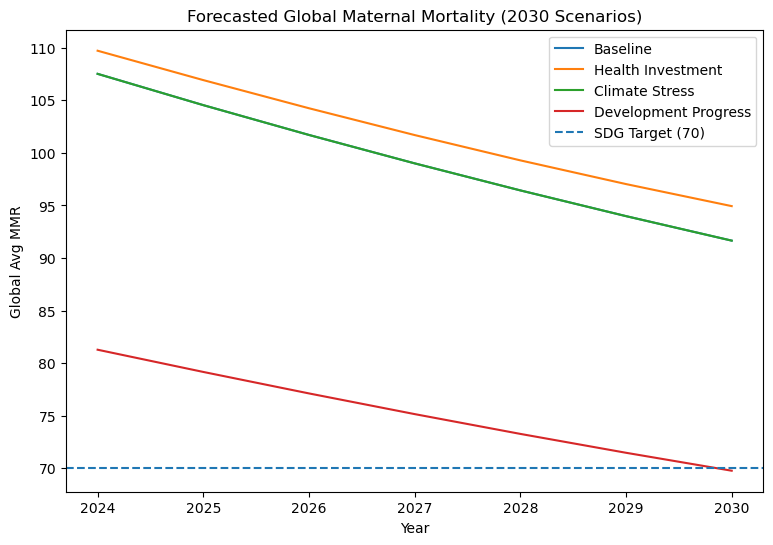

In [218]:
#global forecast visualization
baseline_global = future_baseline.groupby("year")["pred_mmr"].mean()
health_global = future_health.groupby("year")["pred_mmr"].mean()
climate_global = future_climate.groupby("year")["pred_mmr"].mean()
dev_global = future_dev.groupby("year")["pred_mmr"].mean()

plt.figure(figsize=(9,6))

plt.plot(baseline_global, label="Baseline")
plt.plot(health_global, label="Health Investment")
plt.plot(climate_global, label="Climate Stress")
plt.plot(dev_global, label="Development Progress")

plt.axhline(70, linestyle="--", label="SDG Target (70)")

plt.ylabel("Global Avg MMR")
plt.xlabel("Year")
plt.title("Forecasted Global Maternal Mortality (2030 Scenarios)")
plt.legend()
plt.show()

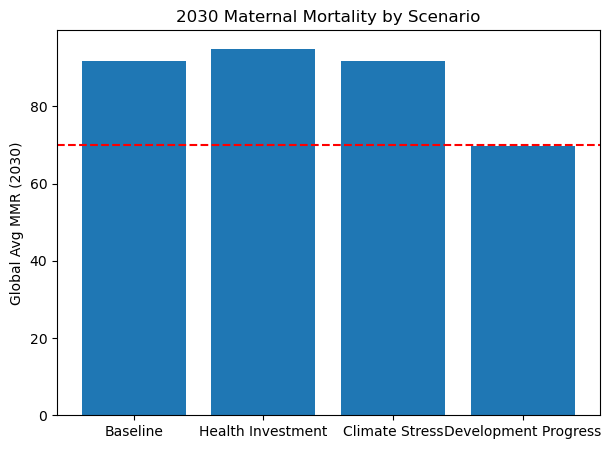

In [221]:
final_year = 2030

vals = {
"Baseline": baseline_global.loc[final_year],
"Health Investment": health_global.loc[final_year],
"Climate Stress": climate_global.loc[final_year],
"Development Progress": dev_global.loc[final_year]
}

plt.figure(figsize=(7,5))
plt.bar(vals.keys(), vals.values())

plt.axhline(70, linestyle="--", color="red")
plt.ylabel("Global Avg MMR (2030)")
plt.title("2030 Maternal Mortality by Scenario")
plt.show()

In [227]:
#causality analysis
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

panel=df.set_index(["iso3c","year"])
y=panel["log_mmr"]
X = panel[[
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days"
]]

X = sm.add_constant(X)

In [229]:
model = PanelOLS(
    y,
    X,
    entity_effects=True
)

results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                log_mmr   R-squared:                        0.2820
Estimator:                   PanelOLS   R-squared (Between):              0.5261
No. Observations:                4998   R-squared (Within):               0.2820
Date:                Thu, Mar 05 2026   R-squared (Overall):              0.5203
Time:                        10:41:31   Log-likelihood                    842.50
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      311.19
Entities:                         238   P-value                           0.0000
Avg Obs:                       21.000   Distribution:                  F(6,4754)
Min Obs:                       21.000                                           
Max Obs:                       21.000   F-statistic (robust):             38.106
                            

/opt/anaconda3/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
